# Mixed distributions in QMCPy

## 1. Problem statement

A mixed distribution combines component probability measures
$P_0,\ldots,P_{s-1}$ as

$$
P_{\mathrm{mix}} = \sum_{j=0}^{s-1} p_j P_j,
\qquad p_j > 0,
\qquad \sum_{j=0}^{s-1} p_j = 1.
$$

When the components have densities or weights $\rho_j$ with respect to a
common reference measure, the corresponding mixture is

$$
\rho_{\mathrm{mix}}(x) = \sum_{j=0}^{s-1} p_j\rho_j(x).
$$

The measure-level definition also covers components with point masses, which need not have an ordinary smooth density. This notebook focuses on sampling and on what the extra selector coordinate means in practice.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/mixed_distributions.ipynb)

In [ ]:
# @title Execute this cell to install dependencies
try:
  import google.colab
  IN_COLAB = True
except ImportError:
  IN_COLAB = False
if IN_COLAB:
  !pip install -q qmcpy


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qmcpy import (
    DigitalNetB2,
    Gaussian,
    Kumaraswamy,
    Mixture,
    StudentT,
    Triangular,
    ZeroInflatedExpUniform,
)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#3366CC", "#E67300", "#2E8B57"]

## 2. What was missing before

Individual `TrueMeasure`s already know how to transform standard-uniform coordinates and how to evaluate their weights. What was missing was a small coordinator that could choose among those existing transforms without reimplementing any component distribution.

## 3. The $d+1 \rightarrow d$ selector transform

For an output in $\mathbb{R}^d$, `Mixture` consumes
$u=(u_0,u_1,\ldots,u_d)\in[0,1]^{d+1}$. The first coordinate selects component
$j$ through

$$
p_0+\cdots+p_{j-1} < u_0 \le p_0+\cdots+p_j,
$$

and only $(u_1,\ldots,u_d)$ enters that component's recursive transform. Thus
the outer sampler has dimension `d + 1`, while the returned samples have last
axis `d`.

## 4. A simple two-component introduction

Two separated Gaussians make the selector easy to see. This is the notebook's
only one-dimensional Gaussian-focused example: $u_0\le0.3$ chooses the
left component, and $u_0>0.3$ chooses the right component.

In [2]:
intro_components = [
    Gaussian(DigitalNetB2(1, seed=11), mean=-2.0, covariance=0.35),
    Gaussian(DigitalNetB2(1, seed=13), mean=2.5, covariance=0.55),
]
intro_probabilities = np.array([0.3, 0.7])
intro = Mixture(
    DigitalNetB2(2, seed=7), intro_components, intro_probabilities
)

intro_x = intro(2048)[:, 0]

assert intro.d == 1
assert intro.discrete_distrib.d == 2
assert intro_x.shape == (2048,)
print("outer sampler dimension:", intro.discrete_distrib.d)
print("mixture sample shape:   ", intro_x[:, None].shape)

outer sampler dimension: 2
mixture sample shape:    (2048, 1)


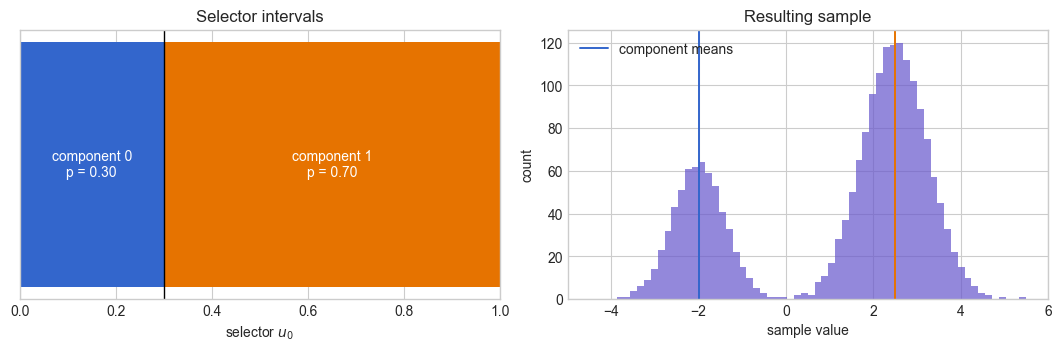

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4), layout="constrained")

axes[0].barh(0, 0.3, left=0.0, color=COLORS[0], height=0.5)
axes[0].barh(0, 0.7, left=0.3, color=COLORS[1], height=0.5)
axes[0].axvline(0.3, color="black", linewidth=1)
axes[0].text(0.15, 0, "component 0\np = 0.30", ha="center", va="center", color="white")
axes[0].text(0.65, 0, "component 1\np = 0.70", ha="center", va="center", color="white")
axes[0].set(xlim=(0, 1), yticks=[], xlabel=r"selector $u_0$", title="Selector intervals")

bins = np.linspace(-4.5, 5.5, 65)
axes[1].hist(intro_x, bins=bins, color="#6A5ACD", alpha=0.72)
axes[1].axvline(-2.0, color=COLORS[0], linewidth=1.4, label="component means")
axes[1].axvline(2.5, color=COLORS[1], linewidth=1.4)
axes[1].set(xlabel="sample value", ylabel="count", title="Resulting sample")
axes[1].legend(frameon=False)
plt.show()

## 5. Exact boundary behavior

`Mixture` uses left-sided cumulative-probability lookup. An exact cumulative boundary belongs to the component on its left; the next representable number above it belongs to the next component. The endpoints `0` and `1` select the first and last components, respectively.

In [4]:
boundary_u = np.array([
    [0.0, 0.5],
    [0.3, 0.5],
    [np.nextafter(0.3, 1.0), 0.5],
    [1.0, 0.5],
])
boundary_x = intro._transform(boundary_u)[:, 0]
boundary_component = np.searchsorted(
    np.cumsum(intro_probabilities), boundary_u[:, 0], side="left"
)
boundary_component = np.minimum(boundary_component, 1)

for selector, component, value in zip(
    boundary_u[:, 0], boundary_component, boundary_x
):
    print(f"u0={selector:.17g} -> component {component} -> x={value:.1f}")

np.testing.assert_array_equal(boundary_component, [0, 0, 1, 1])
np.testing.assert_allclose(boundary_x, [-2.0, -2.0, 2.5, 2.5])

u0=0 -> component 0 -> x=-2.0
u0=0.29999999999999999 -> component 0 -> x=-2.0
u0=0.30000000000000004 -> component 1 -> x=2.5
u0=1 -> component 1 -> x=2.5


## 6. Main heterogeneous mixture

Now the components are genuinely different: a bell-shaped Gaussian, a zero-inflated exponential, and a bounded skewed Kumaraswamy distribution. Their selector intervals are `[0, 0.25]`, `(0.25, 0.65]`, and `(0.65, 1]`.

In [5]:
heterogeneous_components = [
    Gaussian(DigitalNetB2(1, seed=21), mean=-2.2, covariance=0.22),
    ZeroInflatedExpUniform(
        DigitalNetB2(1, seed=22), p_zero=0.45, lam=1.2
    ),
    Kumaraswamy(DigitalNetB2(1, seed=23), a=0.7, b=2.8),
]
heterogeneous_probabilities = np.array([0.25, 0.40, 0.35])
heterogeneous = Mixture(
    DigitalNetB2(2, seed=17),
    heterogeneous_components,
    heterogeneous_probabilities,
)

heterogeneous_x = heterogeneous(4096)[:, 0]
zero_mask = heterogeneous_x == 0

print("observed total zero fraction:", round(zero_mask.mean(), 4))
print("target total zero fraction:  ", 0.40 * 0.45)

observed total zero fraction: 0.1802
target total zero fraction:   0.18000000000000002


## 7. Reading the heterogeneous sample

The continuous values and the atom at zero require different visual marks. The negative bell-shaped cluster comes from the Gaussian, values between zero and one combine the bounded Kumaraswamy behavior with positive exponential values, and the positive tail comes from the exponential component. The histogram below excludes exact zeros. The adjacent bar reports the point-mass count rather than pretending that the atom is part of a smooth density.

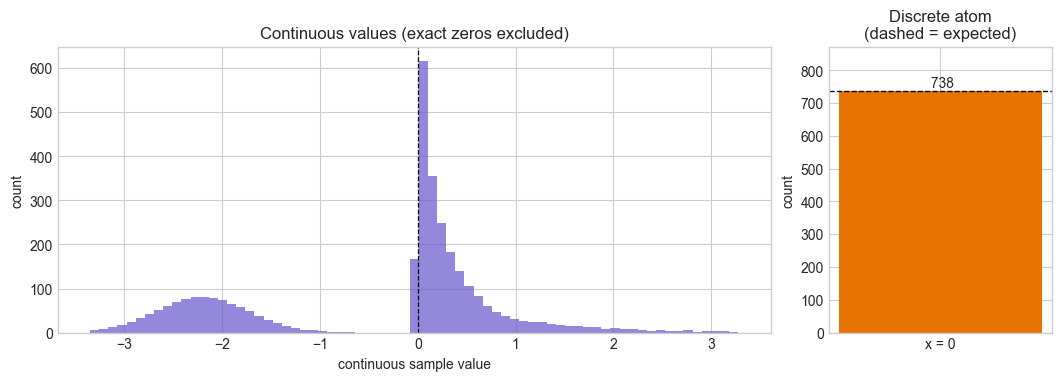

In [6]:
fig, axes = plt.subplots(
    1, 2, figsize=(10.5, 3.7), gridspec_kw={"width_ratios": [3.2, 1]},
    layout="constrained"
)

continuous_values = heterogeneous_x[~zero_mask]
plot_low, plot_high = np.quantile(continuous_values, [0.002, 0.995])
bins = np.linspace(plot_low, plot_high, 72)
axes[0].hist(continuous_values, bins=bins, color="#6A5ACD", alpha=0.72)
axes[0].axvline(0, color="black", linewidth=0.9, linestyle="--")
axes[0].set(
    xlabel="continuous sample value", ylabel="count",
    title="Continuous values (exact zeros excluded)"
)

zero_count = int(zero_mask.sum())
expected_zero_count = len(heterogeneous_x) * 0.40 * 0.45
axes[1].bar(["x = 0"], [zero_count], color=COLORS[1], width=0.55)
axes[1].axhline(expected_zero_count, color="black", linestyle="--", linewidth=1)
axes[1].text(0, zero_count, f" {zero_count}", ha="center", va="bottom")
axes[1].set_ylim(0, max(zero_count, expected_zero_count) * 1.18)
axes[1].set(ylabel="count", title="Discrete atom\n(dashed = expected)")
plt.show()

## 8. Another pair: heavy-tailed and bounded

This short example mixes a Student $t$ distribution with a bounded triangular
distribution. The former can generate heavy tails; the latter stays inside its
finite support and peaks at its mode.

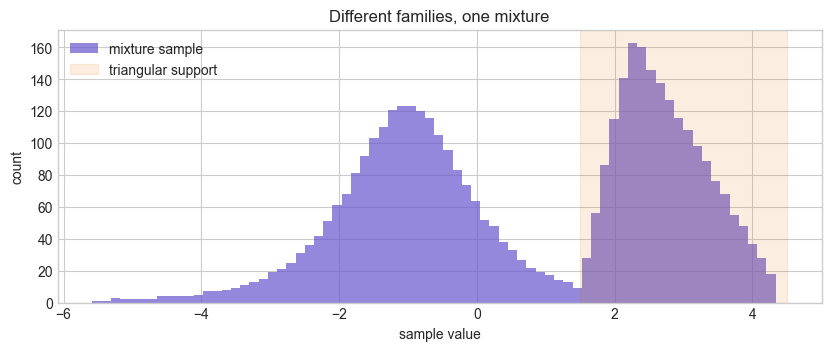

In [7]:
pair_components = [
    StudentT(
        DigitalNetB2(1, seed=31), loc=[-1.0], shape=[[0.8]], df=3
    ),
    Triangular(
        DigitalNetB2(1, seed=32), c=0.25, loc=1.5, scale=3.0
    ),
]
pair_probabilities = np.array([0.55, 0.45])
pair = Mixture(DigitalNetB2(2, seed=29), pair_components, pair_probabilities)

pair_x = pair(4096)[:, 0]
pair_low, pair_high = np.quantile(pair_x, [0.004, 0.996])
pair_bins = np.linspace(pair_low, pair_high, 75)

fig, ax = plt.subplots(figsize=(8.2, 3.4), layout="constrained")
ax.hist(pair_x, bins=pair_bins, color="#6A5ACD", alpha=0.72, label="mixture sample")
ax.axvspan(1.5, 4.5, color=COLORS[1], alpha=0.12, label="triangular support")
ax.set(xlabel="sample value", ylabel="count", title="Different families, one mixture")
ax.legend(frameon=False)
plt.show()

## 9. Multidimensional output

For $d=2$, the outer sampler has three coordinates: one selector and two
coordinates for the chosen component. The returned sample still has only two
coordinates. A compact Gaussian example makes the two clusters easy to inspect.

outer sampler dimension: 3
output sample shape:     (2048, 2)


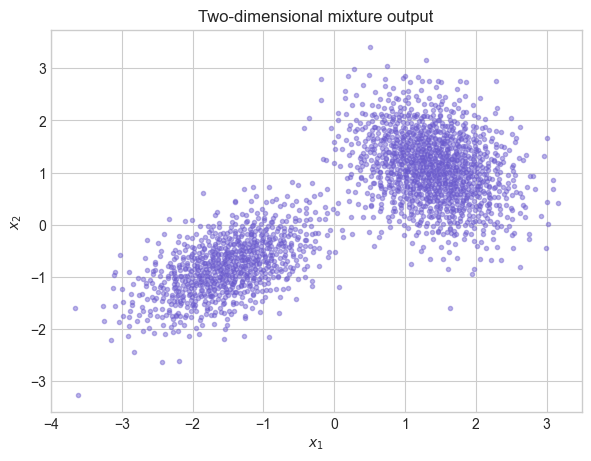

In [8]:
components_2d = [
    Gaussian(
        DigitalNetB2(2, seed=41), mean=[-1.5, -0.8],
        covariance=[[0.45, 0.22], [0.22, 0.35]]
    ),
    Gaussian(
        DigitalNetB2(2, seed=42), mean=[1.4, 1.1],
        covariance=[[0.35, -0.12], [-0.12, 0.5]]
    ),
]
mixture_2d = Mixture(DigitalNetB2(3, seed=39), components_2d, [0.4, 0.6])
x_2d = mixture_2d(2048)

assert mixture_2d.discrete_distrib.d == 3
assert x_2d.shape == (2048, 2)
print("outer sampler dimension:", mixture_2d.discrete_distrib.d)
print("output sample shape:    ", x_2d.shape)

fig, ax = plt.subplots(figsize=(5.8, 4.5), layout="constrained")
ax.scatter(x_2d[:, 0], x_2d[:, 1], s=9, alpha=0.45, color="#6A5ACD")
ax.set(xlabel=r"$x_1$", ylabel=r"$x_2$", title="Two-dimensional mixture output")
plt.show()

## 10. A component may itself be composed

Components are reused through their recursive transform, not just their final `_transform` method. Here a Kumaraswamy transform feeds a Gaussian transform. The first probe point selects that composed component; the second selects a direct triangular component.

In [9]:
inner = Kumaraswamy(DigitalNetB2(1, seed=51), a=2.0, b=5.0)
composed = Gaussian(inner, mean=-1.0, covariance=0.6)
direct = Triangular(DigitalNetB2(1, seed=52), c=0.6, loc=1.0, scale=2.0)
composed_mixture = Mixture(
    DigitalNetB2(2, seed=49), [composed, direct], [0.5, 0.5]
)

probe = np.array([[0.2, 0.2], [0.8, 0.8]])
probe_result = composed_mixture._transform(probe)
recursive_result = composed._jacobian_transform_r(
    probe[:1, 1:], return_weights=False
)
final_transform_only = composed._transform(probe[:1, 1:])

np.testing.assert_allclose(probe_result[:1], recursive_result)
assert not np.allclose(recursive_result, final_transform_only)
print("mixture result:", np.round(probe_result[:, 0], 5))
print("recursive composed result:", np.round(recursive_result[:, 0], 5))

mixture result: [-1.62756  2.43431]
recursive composed result: [-1.62756]


## 11. Replicated sampling

Replications add leading axes but do not change the selector convention. The implementation flattens the leading axes for dispatch and restores them after each selected component has been transformed.

In [10]:
replicated = Mixture(
    DigitalNetB2(2, seed=61, replications=3),
    heterogeneous_components,
    heterogeneous_probabilities,
)
replicated_samples = replicated(32)

assert replicated_samples.shape == (3, 32, 1)
print("replicated output shape:", replicated_samples.shape)

replicated output shape: (3, 32, 1)


## 12. Scope and limitations

- Every component must have the same output dimension, and the outer sampler must have exactly one extra coordinate.
- Probabilities must be finite, strictly positive, and sum to one.
- The reported `range` is a coordinate-wise bounding box; disconnected component supports may make that box wider than the actual union.
- `_weight(x)` is the probability-weighted sum of component weights. It is only as meaningful as those component weights. In particular, a distribution with a point mass, such as `ZeroInflatedExpUniform`, is not an ordinary smooth density with respect to Lebesgue measure; the sampling demonstration above therefore treats its atom separately and does not draw a false density curve.
- Spawning preserves the component dimension and creates a new outer sampler; component objects are shared because their attached samplers are not used by mixture dispatch.

## 13. Summary

`Mixture` adds one selector coordinate around existing `TrueMeasure` behavior. It preserves sample order and leading replication axes, supports heterogeneous and multidimensional components, follows composed transform chains, and forms weights by the usual probability-weighted sum. The examples deliberately span bell-shaped, zero-inflated, bounded skewed, heavy-tailed, triangular, composed, and multivariate behavior rather than treating the feature as only a Gaussian mixture utility.